# Experiments and Results

This notebook loads the saved comparison results and produces all plots and discussion for the experiment.

**Prerequisites:** Run `experiments/compare.py` first to generate `experiments/results/hartmann_comparison/regret_data.pt`.

```bash
cd gp-fatigue-optimizer
python -m experiments.compare
```

In [ ]:
import sys
import os

# Add repo root to path so that src.* and experiments.* imports work
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

import torch
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.dpi"] = 120

## 1.  Load saved results

`load_results()` reads the `.pt` file produced by `compare.py`.
It returns a dict of `(N_SEEDS, N_EVAL)` tensors --> one row per seed, one column per evaluation step.
Each value is the simple regret at that step:

$$r_k = f(x^*) - \max_{i \leq k} f(x_i)$$

In [2]:
from experiments.compare import load_results, plot_regret, COLORS, CONFIG, N_EVAL, N_SEEDS, RESULTS_DIR

results = load_results()

print("Methods:", list(results.keys()))
print("Shape per method:", next(iter(results.values())).shape)  # (N_SEEDS, N_EVAL)
print("Results dir:", RESULTS_DIR)

Loaded results from c:\Users\Win11 Pro\source\repos\gp-fatigue-optimizer\experiments\results\hartmann_comparison\regret_data.pt
  Config: 20 seeds, 60 evals, benchmark=hartmann6d
Methods: ['GP-WLS', 'Vanilla BO', 'ARS', 'Random']
Shape per method: torch.Size([20, 60])
Results dir: c:\Users\Win11 Pro\source\repos\gp-fatigue-optimizer\experiments\results\hartmann_comparison


## 2.  Final regret table

Simple regret at the last evaluation step, averaged over all seeds.

In [3]:
print(f"{'Method':<12}  {'Mean regret':>12}  {'Std':>8}  {'Median':>8}")
print("-" * 46)
for name, regret_matrix in results.items():
    final = regret_matrix[:, -1]   #regret after all N_EVAL evaluations
    print(f"{name:<12}  {final.mean():>12.4f}  {final.std():>8.4f}  {final.median():>8.4f}")

Method         Mean regret       Std    Median
----------------------------------------------
GP-WLS              0.3104    0.5453    0.1372
Vanilla BO          0.2999    0.1016    0.2844
ARS                 0.8759    0.7188    0.4612
Random              1.5602    0.5512    1.5883


## 3.  Regret curves --> log scale

Mean simple regret ± 1 standard deviation over 20 seeds.
Log scale makes early differences visible.

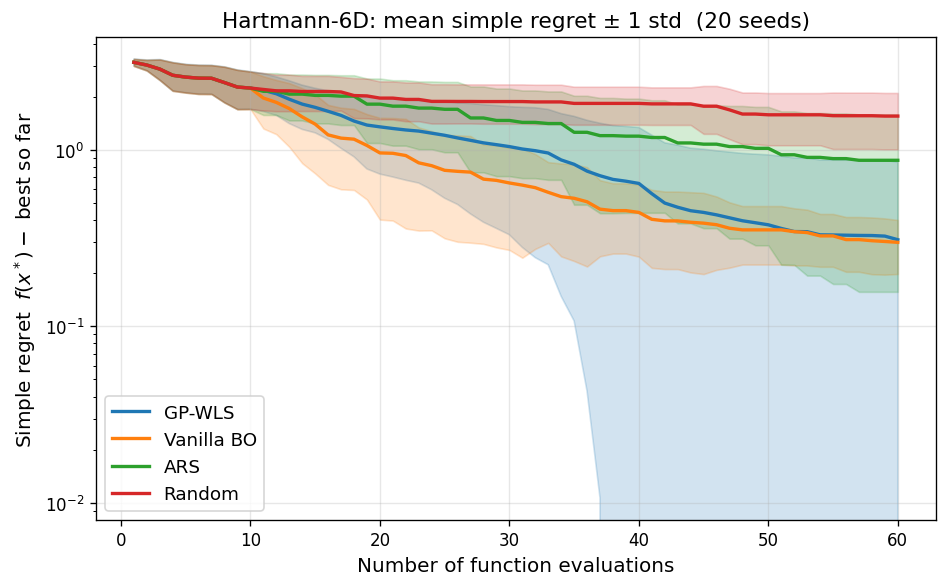

In [4]:
x_axis = torch.arange(1, N_EVAL + 1).numpy()

fig, ax = plt.subplots(figsize=(8, 5))

for name, regret_matrix in results.items():
    mean = regret_matrix.mean(dim=0).numpy()
    std  = regret_matrix.std(dim=0).numpy()
    ax.plot(x_axis, mean, label=name, color=COLORS[name], linewidth=2)
    ax.fill_between(x_axis, mean - std, mean + std, alpha=0.2, color=COLORS[name])

ax.set_xlabel("Number of function evaluations", fontsize=12)
ax.set_ylabel("Simple regret  $f(x^*) - $ best so far", fontsize=12)
ax.set_title(f"Hartmann-6D: mean simple regret ± 1 std  ({N_SEEDS} seeds)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "regret_log.png"), dpi=150)
plt.show()

## 4.  Regret curves --> linear scale

Same data on a linear scale --> shows the absolute gap between methods more clearly.

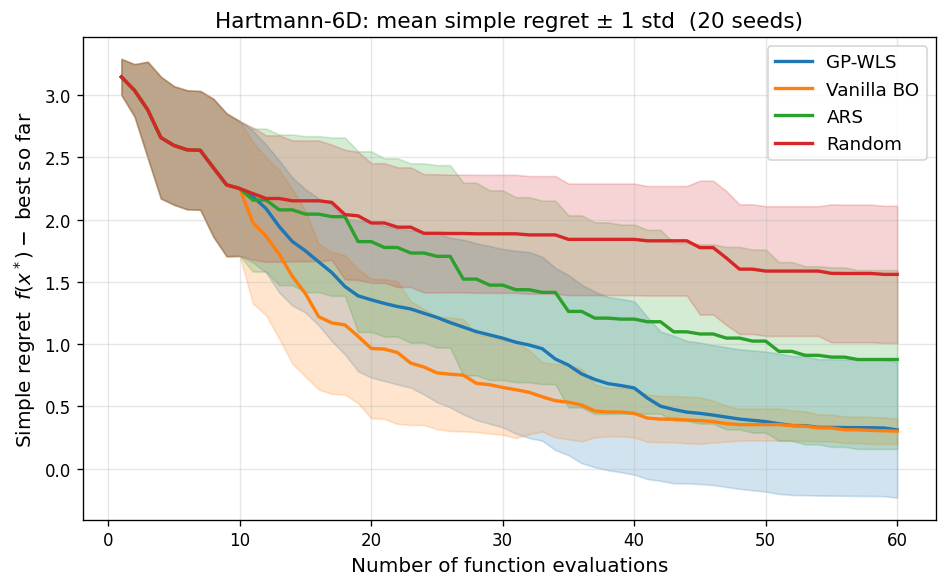

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, regret_matrix in results.items():
    mean = regret_matrix.mean(dim=0).numpy()
    std  = regret_matrix.std(dim=0).numpy()
    ax.plot(x_axis, mean, label=name, color=COLORS[name], linewidth=2)
    ax.fill_between(x_axis, mean - std, mean + std, alpha=0.2, color=COLORS[name])

ax.set_xlabel("Number of function evaluations", fontsize=12)
ax.set_ylabel("Simple regret  $f(x^*) - $ best so far", fontsize=12)
ax.set_title(f"Hartmann-6D: mean simple regret ± 1 std  ({N_SEEDS} seeds)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "regret_linear.png"), dpi=150)
plt.show()

## 5.  Per seed regret at final evaluation

Box plot showing the distribution of final regret across seeds.
Reveals outliers that drive the high standard deviation in GP-WLS.

C:\Users\Win11 Pro\AppData\Local\Temp\ipykernel_5408\4150043598.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, patch_artist=True, medianprops=dict(color="black", linewidth=2))


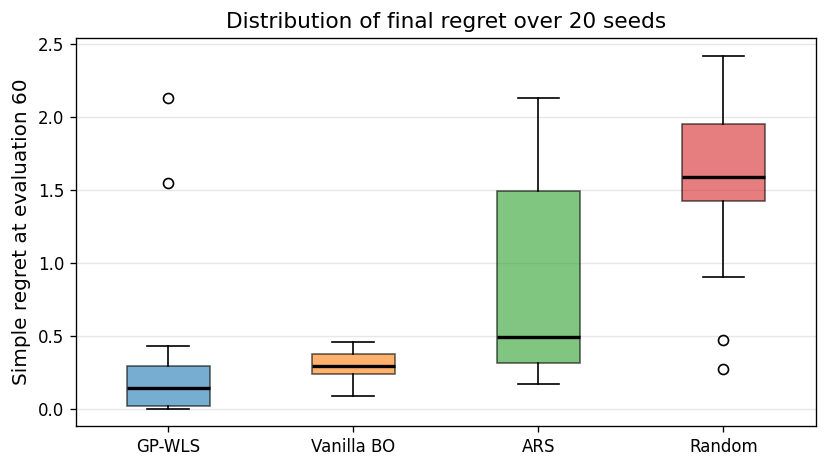

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

names  = list(results.keys())
data   = [results[name][:, -1].numpy() for name in names]
colors = [COLORS[name] for name in names]

bp = ax.boxplot(data, labels=names, patch_artist=True, medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Simple regret at evaluation 60", fontsize=12)
ax.set_title(f"Distribution of final regret over {N_SEEDS} seeds", fontsize=13)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "regret_boxplot.png"), dpi=150)
plt.show()

## 6.  Discussion

### GP-WLS vs Vanilla BO

Both GP-WLS and Vanilla BO reach similar **mean** final regret (~0.30), but GP-WLS has roughly 5× higher standard deviation. This is expected:

- **Vanilla BO** uses UCB = $\mu(x) + \beta \sigma(x)$, which explicitly balances exploration and exploitation. Even if the algorithm gets stuck locally, the uncertainty term pulls candidates toward unexplored regions.
- **GP-WLS** follows $\nabla \mu(x)$ — pure exploitation. If the 10 random init points happen to land near the global optimum, GP-WLS converges very fast (steep drop around eval 35–40). If not, it stays stuck in a local optimum.

This local behaviour is the defining property of **GIBO-style algorithms**: they are fast *given a good base*, but fragile across random seeds.

### ARS

ARS estimates gradients without a surrogate. Each step costs $2 \times N_{\text{dirs}} = 8$ real evaluations. With a budget of 60 evaluations, ARS only takes ~6 effective gradient steps. This explains its slow convergence compared to the GP-based methods.

### Random Search

Random search serves as the lower bound. Any method that cannot beat random search is useless. All three optimizers beat it convincingly.

### The role of Wolfe conditions

The Wolfe conditions control **inner loop termination**: the gradient ascent step in each BO iteration stops when both the Armijo (sufficient increase) and curvature conditions are satisfied. This replaces possible fixed parameters in the inner loop.

The high variance of GP-WLS is not a failure of the Wolfe conditions but a consequence of the local, exploitation only search strategy. A natural extension would be to combine GP-WLS with an explicit exploration phase (e.g., random restarts weighted by posterior uncertainty).